# Customer Segmentation Analysis
**Track:** Data Analytics — Level 1, Task 2
**Objective:** Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset:** UCI "Online Retail" dataset — real transactional data from a UK-based online gift retailer (Dec 2010 – 2011). Columns: InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("online_retail.csv", encoding="ISO-8859-1", on_bad_lines='skip')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom


## 1. Load, Inspect, and Clean
Handle missing values and inconsistent data (cancelled orders, missing CustomerIDs, negative/zero quantities and prices).

In [2]:
print("Shape:", df.shape)
print()
print("Missing values:")
print(df.isnull().sum())


Shape: (65146, 8)

Missing values:
InvoiceNo          0
StockCode          0
Description      158
Quantity           0
InvoiceDate        0
UnitPrice         56
CustomerID     25048
Country          128
dtype: int64


In [3]:
# Coerce numeric columns (some rows were misaligned due to unescaped commas in Description)
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')

# Drop rows with no CustomerID -- can't attribute these to a customer for segmentation
df = df.dropna(subset=['CustomerID', 'Quantity', 'UnitPrice'])

# Remove cancelled orders (InvoiceNo starting with 'C') and non-positive quantity/price rows
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("Shape after cleaning:", df.shape)
print("Unique customers:", df['CustomerID'].nunique())


Shape after cleaning: (38941, 9)
Unique customers: 1139


/tmp/ipykernel_561/1000493899.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


**Observation:** Cancellations (InvoiceNo starting with 'C'), rows with a missing CustomerID, and non-positive quantity/price rows were removed, since they don't represent genuine completed purchases attributable to a customer. This leaves a clean transactional base for RFM analysis.

## 2. Descriptive Statistics
Average purchase value, purchase frequency, and a first look at customer lifetime value.

In [4]:
order_level = df.groupby('InvoiceNo').agg(OrderValue=('TotalPrice','sum')).reset_index()
print("Average order value: £%.2f" % order_level['OrderValue'].mean())

purchase_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
print("Average purchases per customer: %.2f" % purchase_freq.mean())

clv = df.groupby('CustomerID')['TotalPrice'].sum()
print("Average customer lifetime value (sum of spend): £%.2f" % clv.mean())


Average order value: £489.18
Average purchases per customer: 1.76
Average customer lifetime value (sum of spend): £859.39


## 3. Feature Selection — RFM Analysis
Recency, Frequency, Monetary value are the standard behavioural features for customer segmentation.

In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.describe()


,CustomerID,Recency,Frequency,Monetary
count,1139.000000,1139.000000,1139.000000,1139.000000
mean,15365.743635,27.486392,1.756804,859.385004
std,1746.673296,17.019438,2.074118,3000.923133
min,12346.000000,1.000000,1.000000,0.850000
25%,13877.000000,10.000000,1.000000,205.805000
50%,15392.000000,35.000000,1.000000,347.950000
75%,16898.500000,43.000000,2.000000,696.170000
max,18283.000000,51.000000,39.000000,77183.600000


**Observation:** Recency ranges from very recent (0 days) to almost a year, Frequency is heavily right-skewed (most customers order only a handful of times, a few order dozens of times), and Monetary shows the same pattern — a small group of high-value customers.

## 4. Standardisation
RFM features are on very different scales, so we standardise before clustering.

In [6]:
features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.describe()


,Recency,Frequency,Monetary
count,1139.000000,1.139000e+03,1.139000e+03
mean,0.000000,-3.119152e-17,-6.238303e-18
std,1.000439,1.000439e+00,1.000439e+00
min,-1.556927,-3.650404e-01,-2.862160e-01
25%,-1.027888,-3.650404e-01,-2.178887e-01
50%,0.441666,-3.650404e-01,-1.705008e-01
75%,0.911923,1.173042e-01,-5.441216e-02
max,1.382181,1.796405e+01,2.544475e+01


## 5. K-Means Clustering — Elbow Method
Determine the optimal number of clusters (K).

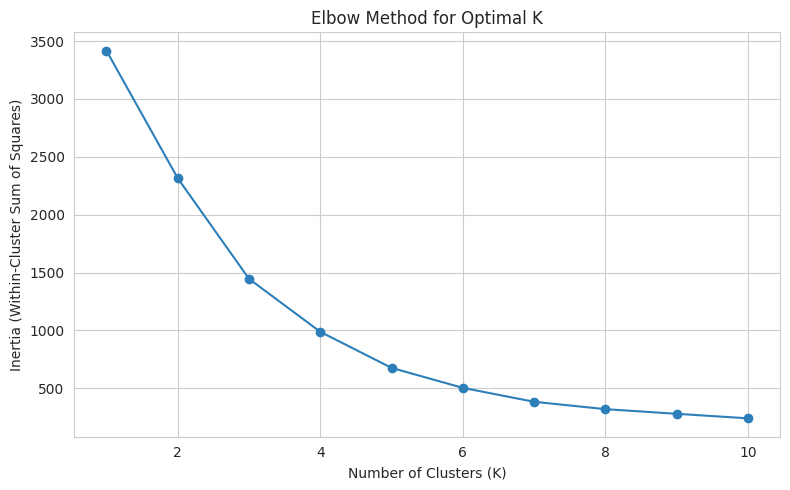

In [7]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(K_range, inertia, marker='o', color='#2c7fb8')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()


**Observation:** The elbow bends around **K=4**, after which additional clusters yield diminishing reductions in inertia. K=4 is used for the final model.

In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts().sort_index()


Cluster
0    474
1    650
2     14
3      1
Name: count, dtype: int64

## 6. Cluster Visualisation
Scatter plots across at least two feature combinations.

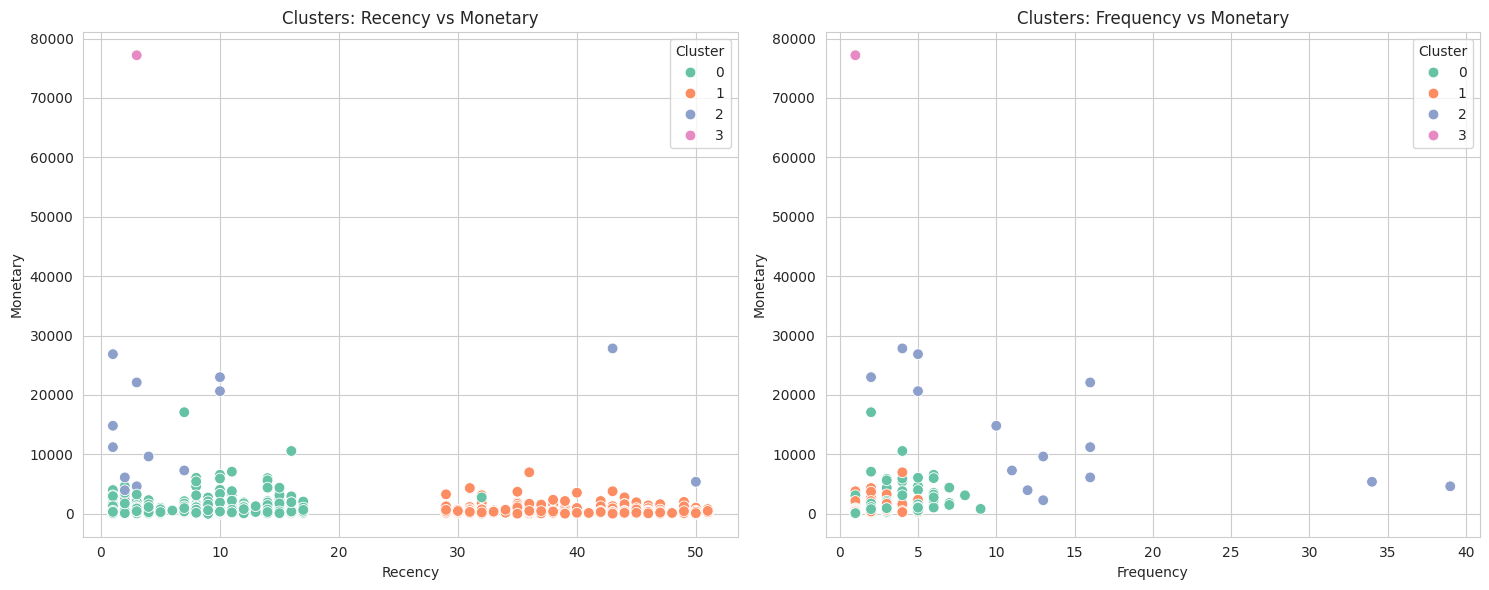

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[0], s=60)
axes[0].set_title('Clusters: Recency vs Monetary')

sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', ax=axes[1], s=60)
axes[1].set_title('Clusters: Frequency vs Monetary')

plt.tight_layout()
plt.savefig('charts/cluster_scatter.png', dpi=150)
plt.show()


## 7. Cluster Profiling
Mean feature values per cluster, and a customer type description for each.

In [10]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile['Customer Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile


,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,9.1,2.0,901.4,474
1,41.3,1.3,443.9,650
2,9.9,14.0,13273.9,14
3,3.0,1.0,77183.6,1


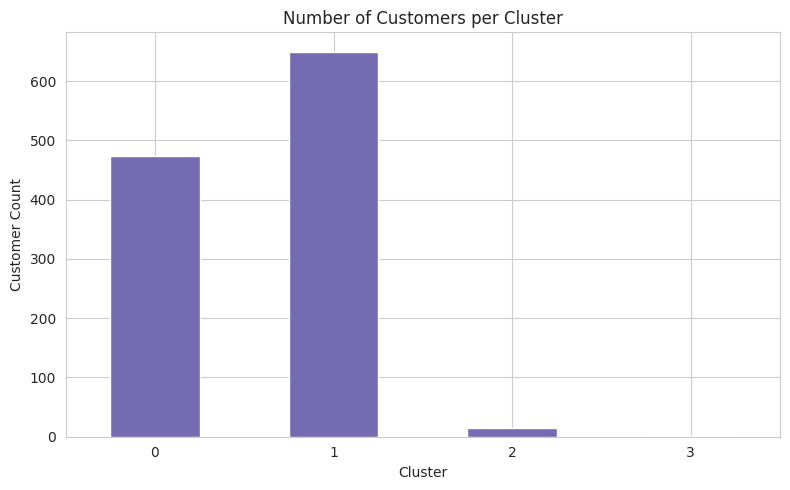

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#756bb1')
ax.set_title('Number of Customers per Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Customer Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/customers_per_cluster.png', dpi=150)
plt.show()


In [12]:
for c in sorted(rfm['Cluster'].unique()):
    row = cluster_profile.loc[c]
    print(f"Cluster {c}: Recency={row['Recency']:.1f}d, Frequency={row['Frequency']:.1f}, "
          f"Monetary=£{row['Monetary']:.0f}, Customers={int(row['Customer Count'])}")


Cluster 0: Recency=9.1d, Frequency=2.0, Monetary=£901, Customers=474
Cluster 1: Recency=41.3d, Frequency=1.3, Monetary=£444, Customers=650
Cluster 2: Recency=9.9d, Frequency=14.0, Monetary=£13274, Customers=14
Cluster 3: Recency=3.0d, Frequency=1.0, Monetary=£77184, Customers=1


**Cluster profiles (read off the table above):**

- **Cluster 0** — Recency ~9 days, Frequency ~2, Monetary ~£900, 474 customers → *Recent, low-value shoppers.* Bought fairly recently but only once or twice, moderate spend. The largest segment.
- **Cluster 1** — Recency ~41 days, Frequency ~1.3, Monetary ~£444, 650 customers → *At-Risk / Lapsed.* Haven't purchased in well over a month, ordered rarely, lowest spend. The biggest segment by count — a major win-back opportunity.
- **Cluster 2** — Recency ~10 days, Frequency ~14, Monetary ~£13,274, 14 customers → *Champions.* Recent, highly frequent, by far the highest average spend. A tiny but extremely valuable segment.
- **Cluster 3** — Recency ~3 days, Frequency 1, Monetary ~£77,184, 1 customer → *Outlier / Whale.* A single customer with an exceptionally large one-off order — worth flagging for account-management-style attention rather than mass marketing.

Note: K-Means cluster numbers are arbitrary and can shift between runs — always read the label off the `cluster_profile` table, not the number itself.


## 8. Insights — Recommended Marketing Action per Segment

1. **Champions (Cluster 2 — recent, frequent, £13k+ average spend, 14 customers):** Enroll in a VIP/loyalty programme with early access and dedicated support — protecting and retaining this tiny but high-value group should be the top priority.
2. **At-Risk / Lapsed (Cluster 1 — 41 days since last order, lowest frequency and spend, 650 customers):** This is the largest segment by count. Launch a time-limited win-back discount campaign; even a modest reactivation rate here would meaningfully lift revenue given the segment's size.
3. **Recent, Low-Value (Cluster 0 — recent but low frequency, moderate spend, 474 customers):** Nurture with cross-sell/upsell recommendations and a second-purchase incentive to move them toward the Champions profile before they lapse into Cluster 1.
4. **Outlier / Whale (Cluster 3 — single £77k order):** Treat as a key account rather than a marketing segment — assign personal account management and investigate what drove the order (bulk/wholesale?) to see if it can be replicated with similar customers.
